In [1]:
# The Supervised Machine Learning Process
##########################################  Step 1 Data Wrangling & prerocessing #####################
# Step 1 Part 0 Installing machine learning libraries and data wrangling libraries = Done
# Step 1 Part 1 Importing libraries = Done
# Step 1 part 2 Importing dataset = Done (imported into and sql database and then export into csv)
# Step 1 part 3 Taking care of missing data and duplicates = Done (no missing data or duplicates)
# Step 1 part 4 Encoding categorical data = Done, no need for missing but the dataset is checked!
# Step 1 part 5 Feature selection (creating a matrix of features, and the dependant variable we are predicting = Done, machine learning process expects these two entities)
# Step 1 part 6 Splitting dataset into training and test
# Step 1 part 7 Feature scaling
######################################### S# step 2 Simple Linear regression ##############################
# Step 2 Part 0 
# Step 2 Part 1 
# Step 2 part 2 

######################################### Step 3 Logistic regression #############################

# Step 3 Part 0 
# Step 3 Part 1 
# Step 3 part 2 

######################################### Step 4 K Nearest Neighbors (KNN) ####################### 

# Step 4 Part 0 
# Step 4 Part 1 
# Step 4 part 2 

######################################### Step 5 Support vector machines ######################### 

# Step 5 Part 0 
# Step 5 Part 1 
# Step 5 part 2 

######################################### Step 7 Naive Bayes #################### 

# Step 6 Part 0 
# Step 6 Part 1 
# Step 6 part 2 

######################################### Step 6 Decision Trees ##################################

# Step 7 Part 0 
# Step 7 Part 1 
# Step 7 part 2 

######################################### Step 8 Random Forest classification #################### 
# Step 8 Part 0 
# Step 8 Part 1 
# Step 8 part 2 


######################################### THE END #############################


################# Resources and Datasets ########################

###########https://data.mendeley.com/datasets/6tm2d6sz7p/1 ###### Dataset.csv #### Published: 7 June 2023 (0=legitimate,1=phishing)
#df_Dataset = pd.read_csv('datasets/Dataset.csv')

################# Machine learning resoruces 
# https://www.youtube.com/watch?v=i_LwzRVP7bg&t=2687s


In [2]:
# Step 1 Part 0 Installing machine learning libraries and data wrangling libraries = Done

import sys
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install scikit-learn

In [3]:
# Step 1 Part 1 Importing libraries = Done

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
# Step 1 part 2 Importing dataset, creating a matrix of features, and the dependant variable we are predicting = Done, machine learning process expects these two entities
#read the index.csv file and convert it into a data frame    
df_phishing_csv = pd.read_csv('datasets/phishing_dataset.csv')

In [5]:
# Step 1 part 2 
df_phishing_csv

,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Class
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11050,11051,1,-1,1,-1,1,1,1,1,-1,...,-1,-1,1,1,-1,-1,1,1,1,1
11051,11052,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,1,1,1,1,1,1,-1,1,-1
11052,11053,1,-1,1,1,1,-1,1,-1,-1,...,1,1,1,1,1,-1,1,0,1,-1
11053,11054,-1,-1,1,1,1,-1,-1,-1,1,...,-1,1,1,1,1,-1,1,1,1,-1


In [6]:
# Step 1 part 2 #describe dataset
df_phishing_csv.describe()

,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Class
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,5528.000000,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,...,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584,0.113885
std,3191.447947,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,...,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437,0.993539
min,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2764.500000,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,5528.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,8291.500000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,11055.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
# Step 1 part 2 #number of records and features (247950 records with 42 features)
df_phishing_csv.shape

(11055, 32)

In [8]:
# Step 1 part 2 #information about columns and data types
df_phishing_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   index                        11055 non-null  int64
 1   having_IPhaving_IP_Address   11055 non-null  int64
 2   URLURL_Length                11055 non-null  int64
 3   Shortining_Service           11055 non-null  int64
 4   having_At_Symbol             11055 non-null  int64
 5   double_slash_redirecting     11055 non-null  int64
 6   Prefix_Suffix                11055 non-null  int64
 7   having_Sub_Domain            11055 non-null  int64
 8   SSLfinal_State               11055 non-null  int64
 9   Domain_registeration_length  11055 non-null  int64
 10  Favicon                      11055 non-null  int64
 11  port                         11055 non-null  int64
 12  HTTPS_token                  11055 non-null  int64
 13  Request_URL                  11055 non-null  i

In [9]:
# Step 1 part 3 Taking care of missing data
# Check for missing values
print(df_phishing_csv.isnull().sum())

index                          0
having_IPhaving_IP_Address     0
URLURL_Length                  0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistica

In [10]:
# Step 1 part 3 Taking care of missing data
print(df_phishing_csv.isnull().sum())
#checking for unique records on each column
print(df_phishing_csv['Class'].nunique())

index                          0
having_IPhaving_IP_Address     0
URLURL_Length                  0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistica

In [11]:
#Step 1 part 4 Encoding categorical data, i.e show any unique values in the column "result"

print(df_phishing_csv['Class'].nunique())

2


In [12]:
# Step 1 part 4 #distribution of categorical data in column result,

print(df_phishing_csv['Class'].value_counts())

 1    6157
-1    4898
Name: Class, dtype: int64


In [13]:
# Step 1 part 3 Taking care of missing data
print(df_phishing_csv.isnull().sum())
#checking for unique records on each column
print(df_phishing_csv['Class'].nunique())

index                          0
having_IPhaving_IP_Address     0
URLURL_Length                  0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistica

In [14]:
# Step 1 part 4 #distribution of categorical data in column result,


In [15]:
# Step 1 part 4 Encoding categorical data 
#distribution of categorical data in column Type
#Column Type has already 1 & 0 therefore there is no need to encode the data into categorical values
print(df_phishing_csv['Class'].value_counts())

 1    6157
-1    4898
Name: Class, dtype: int64


In [16]:
# Step 1 part 5 Feature selection (creating a matrix of features from the dataset)

X = df_phishing_csv.iloc[:, 1:-1].values #get all valriable (features) except the first and last column
y = df_phishing_csv.iloc[:, -1].values #get all pridictive values in the first column

In [17]:

print(X)

[[-1  1  1 ...  1  1 -1]
 [ 1  1  1 ...  1  1  1]
 [ 1  0  1 ...  1  0 -1]
 ...
 [ 1 -1  1 ...  1  0  1]
 [-1 -1  1 ...  1  1  1]
 [-1 -1  1 ... -1  1 -1]]


In [18]:
print(y)

[-1 -1 -1 ... -1 -1 -1]


In [19]:
# Step 1 part 6 (Option 1) Splitting dataset into training and test

# valid dataset i.e used to ensure that the model can  handle unseen data after training
# training dataset i.e used to train the model
# test dataset i.e use to evaluate the model

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 1)

In [20]:
# Step 1 part 6 (Option 2) Splitting dataset into training and test
# training: 0-60%
# validation :60-80%
# test: 80-100%

#train, valid, test = np.split(df_phishing_csv.sample(frac=1), [int(0.6*len(df_phishing_csv)), int(0.8*len(df_phishing_csv))])

In [21]:
#Alternative test and pliting

# def scale_dataset(dataframe, oversample=False):
#   X = dataframe[dataframe.columns[:-1]].values
#   y = dataframe[dataframe.columns[-1]].values

#   scaler = StandardScaler()
#   X = scaler.fit_transform(X)

#   if oversample:
#     ros = RandomOverSampler()
#     X, y = ros.fit_resample(X, y)

#   data = np.hstack((X, np.reshape(y, (-1, 1))))

#   return data, X, y

In [22]:
# Step 1 part 6a X training data set
X_train

array([[ 1,  1,  1, ...,  1,  1,  1],
       [-1,  1,  1, ..., -1,  0,  1],
       [-1,  1,  1, ...,  1,  0,  1],
       ...,
       [ 1, -1,  1, ...,  1,  1,  1],
       [-1,  1,  1, ...,  1,  0,  1],
       [ 1, -1,  1, ...,  1,  0,  1]])

In [23]:
# # Step 1 part 6b X test set dataset
X_test

array([[-1, -1,  1, ...,  1,  1,  1],
       [ 1, -1,  1, ...,  1,  0,  1],
       [-1, -1, -1, ..., -1, -1,  1],
       ...,
       [-1,  1, -1, ..., -1,  1,  1],
       [ 1, -1,  1, ...,  1,  1, -1],
       [-1, -1,  1, ...,  1,  1,  1]])

In [24]:
# # Step 1 part 6c y train set
y_train

array([-1, -1,  1, ...,  1,  1,  1])

In [25]:
# Step 1 part 7 Feature scaling ( prevent one feature to dominate the other), get the mean and the sd of your feature
# not neccessary at the moment

In [26]:
######################################### # step 2 Simple Linear regression ##############################

from sklearn.linear_model import LinearRegression # Import a linear regression model
regressor = LinearRegression()
regressor.fit(X_train, y_train) # fit method to train the  simple linear regression model on the training set


LinearRegression()

In [27]:
### predict the test set results
y_pred = regressor.predict(X_test)

ValueError: x and y must be the same size

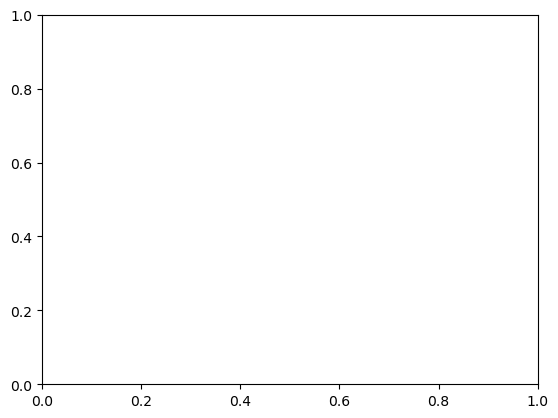

In [28]:
#Visualising the Training set results
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Phishing attack vs websites/URL (Training set)')
plt.xlabel(' Websites/URl')
plt.ylabel('Phishing attacks')
plt.show()

In [29]:
print(len(X_train))

8291


In [30]:
print(len(y_train))

8291


ValueError: x and y must be the same size

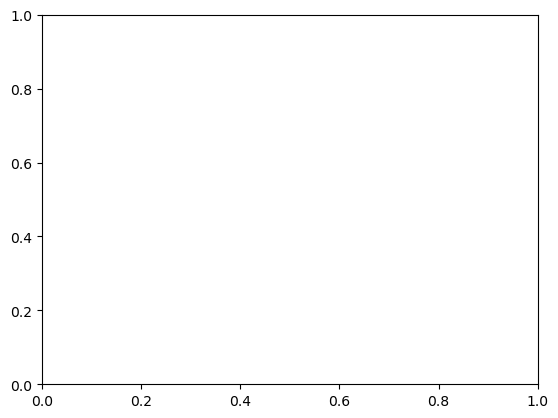

In [31]:
#Visualising the test set results
plt.scatter(X_test, y_test, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Phishing attack vs websites/URL (Test set)')
plt.xlabel(' Websites/URl')
plt.ylabel('Phishing attacks')
plt.show()